# Evaluating bonds
The main purpose of LACAN is looking at bonds in molecules and scoring how unlikely they are to occur based on known co-occurrence relations of fragments. The below example shows a typical functionality of this type, an alkoxyamine, which is penalized by LACAN.

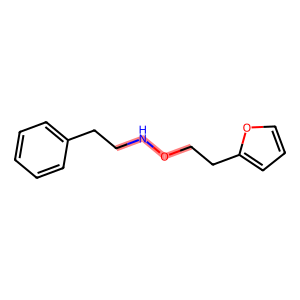

In [1]:
from lacan import lacan
from rdkit import Chem
from rdkit.Chem import Draw

# load lacan profile
p = lacan.load_profile("chembl")
# load molecule
m = Chem.MolFromSmiles("c1ccccc1CCN(OCCc1occc1)")
# score the molecule
score,info = lacan.score_mol(m,p)
# visualize the rejected bond(s)
d = Draw.MolToImage(m,highlightBonds=info["bad_bonds"])
display(d)

# changing the profile
LACAN is based on a profile of a reference set. The standard profile is based on a filtered subset of ChEMBL with PAINS, covalent compounds and others removed. However, it is up to the user to select which profile is appropriate. We also provide the unfiltered ChEMBL profile. Below you can see how this can leads to different results: the unfiltered ChEMBL profile considers acrylamide michael acceptors as normal.

problem bonds highlighted by filtered(normal) profile:


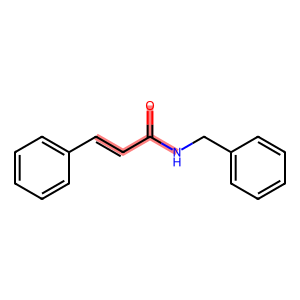

problem bonds highlighted by unfiltered profile:


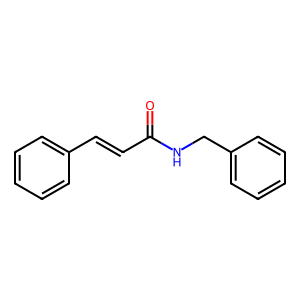

In [2]:
# load molecule
m = Chem.MolFromSmiles("c1ccccc1C=CC(=O)NCc1ccccc1")
# load lacan profile
p = lacan.load_profile("chembl")
# score the molecule
score,info = lacan.score_mol(m,p)
# visualize the rejected bond(s)
print("problem bonds highlighted by filtered(normal) profile:")
d = Draw.MolToImage(m,highlightBonds=info["bad_bonds"])
display(d)
# load lacan profile
p = lacan.load_profile("chembl_full")
# score the molecule
score,info = lacan.score_mol(m,p)
# visualize the rejected bond(s)
print("problem bonds highlighted by unfiltered profile:")
d = Draw.MolToImage(m,highlightBonds=info["bad_bonds"])
display(d)